In [1]:
import varray as va
import numpy as np
import matplotlib.pyplot as plt
import ldax_processing as ldax
from scipy.optimize import curve_fit
from matplotlib import colors
import matplotlib
import hist
from matplotlib.colors import LogNorm
from hist import Hist
import tqdm
from datetime import datetime
from zoneinfo import ZoneInfo
from scipy.stats import binned_statistic_2d
plt.style.use('../style.mplstyle')

In [3]:
RQ_file_path = '/mnt/drive2/TPC_RQs/proc_settings_amp50V_v004/'
file_list = [#'2026-07-06-1546,50',
             #'2026-06-18-1516,50',
             #'2026-07-10-1307,50',
             #'2026-07-10-1631,50',
             #'2026-07-08-1045,50',
             #'2026-07-10-0919,50',
             #'2026-07-09-1213,33',
             #'2026-07-13-0854,50',
             #'2026-07-13-1303,50',
             '2026-07-15-1418,50'
            ]
file_list_labels = [#'Cs137-A:3.3kV-C:-1.5kV-1000/120',
                    #'AmBe-A:3kV-C:-1.5kV-5000/200',
                    #'AmBe-A:3.3kV-C:-2.0kV-1000/120',
                    #'AmBe-A:3.3kV-C:-1.5kV-1000/120',
                    #'AmBe-A:3.3kV-C:-1.5kV-5000/200',
                    #'AmBe-A:3.3kV-C:-0.8kV-1000/120',
                    #'Bkg-A:3.3kV-C:-1.5kV-5000/200',
                    #'AmBe-A:3.3kV-C:-1.5kV-1000/120',
                    #'Bkg-A:3.3kV-C:-1.5kV-1000/120',
                    'DopedBa133-A:3.3kV-C:-1.5kV-1000/120',
                    ]

In [4]:
file='2026-07-15-1418_000000'
file_name_and_path = RQ_file_path+file+'_RQ.vrz'
d = va.load(file_name_and_path)
print(d.keys())

dict_keys(['p_bnds', 'p_area', 'p_area_ch', 'p_phe', 'p_phe_ch', 'p_height', 'p_height_ch', 'p_aft', 'p_width_1090', 'p_width_2575', 'p_nfold', 'p_class', 'p_cut_s1_prominent', 'p_cut_s2_prominent', 's1_area', 's1_area_ch', 's1_phe', 's1_phe_ch', 's1_height', 's1_height_ch', 's1_pulse_bounds', 's1_aft', 's1_width1090', 's1_maf', 's1_mhf', 's2_area', 's2_area_ch', 's2_phe', 's2_phe_ch', 's2_height', 's2_height_ch', 's2_pulse_bounds', 's2_aft', 's2_width1090', 's2_drift_time', 's2_x_raw', 's2_y_raw', 's2_x_bot', 's2_y_bot', 's1_x_top', 's1_y_top', 's1_x_bot', 's1_y_bot', 's2_var_x_raw', 's2_var_y_raw', 's2_var_xy_raw', 's2_var_x_bot', 's2_var_y_bot', 's2_var_xy_bot', 's1_var_x_top', 's1_var_y_top', 's1_var_xy_top', 's1_var_x_bot', 's1_var_y_bot', 's1_var_xy_bot', 's2_r_raw', 's2_theta_raw', 'h_num_events_in_file', 'h_num_samples', 'h_num_channels', 'h_num_events_read', 'h_filename', 'conf_file', 'config_version', 'sipm_spe_areas', 'ldax_processing_version', 'ldax_analysis_version', 'e_ev

In [3]:
def getRQs(file, startPoint=0):
    RQs = {}
    RQs['ss_s2_drift_time'] = np.array([])
    RQs['ss_s1_area'] = np.array([])
    RQs['ss_s1_maf'] = np.array([])
    RQs['ss_s1_mhf'] = np.array([])
    RQs['ss_s1_bot'] = np.array([])
    RQs['ss_s1_top'] = np.array([])
    RQs['ss_s1_tba'] = np.array([])
    RQs['ss_s1_height'] = np.array([])
    RQs['ss_s1_width1090'] = np.array([])
    RQs['ss_s1_aft10'] = np.array([])
    RQs['ss_s2_area'] = np.array([])
    RQs['ss_s2_xpos'] = np.array([])
    RQs['ss_s2_ypos'] = np.array([])
    RQs['ss_s2_rpos'] = np.array([])
    RQs['ss_s2_thetapos'] = np.array([])
    RQs['ss_s2_width1090'] = np.array([])
    RQs['ss_s2_width595'] = np.array([])
    RQs['ss_s2_height'] = np.array([])
    RQs['ss_s2_aft10'] = np.array([])
    RQs['ss_good_area'] = np.array([])
    RQs['ss_bad_area'] = np.array([])
    RQs['ss_event_id'] = np.array([])
    RQs['ss_file_id'] = np.array([])
    RQs['ss_s2_bot'] = np.array([])
    RQs['ss_s2_top'] = np.array([])
    RQs['ss_s2_tba'] = np.array([])
    RQs['ss_s2_maf'] = np.array([])
    RQs['ss_s2_mhf'] = np.array([])
    RQs['ss_trig_timestamp'] = np.array([])

    date = file.split(",")[0]
    numOfFiles = int(file.split(",")[1])
    startTime = 0
    for i in tqdm.tqdm(range(startPoint, numOfFiles)):

        if i < 10:
            file = date + "_00000" + str(i)
        elif i < 100:
            file = date + "_0000" + str(i)
        else:
            file = date + "_000" + str(i)

        file_name_and_path = RQ_file_path+file+'_RQ.vrz'
        d = va.load(file_name_and_path)
        drift_time = np.array(d['ss_s2_drift_time'])
        if i == 0:
            startTime = np.array([d['e_timestamps']])[0,0]

        s1_area = np.array(d['ss_s1_phe'])
        s1_bot = np.sum(np.array(d['ss_s1_phe_ch'])[-16:], axis=0)
        s1_top = np.sum(np.array(d['ss_s1_phe_ch'])[:16], axis=0)
        s1_tba = (s1_top - s1_bot)/s1_area

        s1_height = np.array(d['ss_s1_height'])
        s1_mhf = np.max(np.array(d['ss_s1_height_ch']), axis=0)/s1_height
        s1_width1090 = np.array(d['ss_s1_width1090'])
        s1_aft10 = np.array(d['ss_s1_aft'])[1]
        s1_maf = np.array(d['ss_s1_maf'])

        s2_area = np.array(d['ss_s2_phe'])
        s2_bot = np.sum(np.array(d['ss_s2_phe_ch'])[-16:], axis=0)
        s2_top = np.sum(np.array(d['ss_s2_phe_ch'])[:16], axis=0)
        s2_tba = (s2_top - s2_bot)/s2_area
        s2_maf = np.max(np.array(d['ss_s2_phe_ch']), axis=0)/s2_area

        s2_xpos = np.array(d['ss_s2_x_raw'])
        s2_ypos = np.array(d['ss_s2_y_raw'])
        s2_rpos = np.array(d['ss_s2_r_raw'])
        s2_thetapos = np.array(d['ss_s2_theta_raw'])
        s2_width1090 = np.array(d['ss_s2_width1090'])
        s2_width595 = np.array(d['ss_s2_aft'])[6] - np.array(d['ss_s2_aft'])[0]
        s2_height = np.array(d['ss_s2_height'])
        s2_mhf = np.max(np.array(d['ss_s2_height_ch']), axis=0)/s2_height

        s2_aft10 = np.array(d['ss_s2_aft'])[1]
        good_area = s1_area + s2_area
        bad_area = np.array(d['ss_bad_phe'])
        event_id = np.array(d['ss_e_event_id'])
        ss_trig_timestamp = (np.array([d['ss_e_timestamps']]) - startTime)*10**-8
        ss_trig_timestamp = np.array(ss_trig_timestamp[0])

        RQs['ss_s2_drift_time'] = np.concatenate((RQs['ss_s2_drift_time'], drift_time))
        
        RQs['ss_s1_area'] = np.concatenate((RQs['ss_s1_area'], s1_area))
        RQs['ss_s1_maf'] = np.concatenate((RQs['ss_s1_maf'], s1_maf))
        RQs['ss_s1_mhf'] = np.concatenate((RQs['ss_s1_mhf'], s1_mhf))
        RQs['ss_s1_bot'] = np.concatenate((RQs['ss_s1_bot'], s1_bot))
        RQs['ss_s1_top'] = np.concatenate((RQs['ss_s1_top'], s1_top))
        RQs['ss_s1_tba'] = np.concatenate((RQs['ss_s1_tba'], s1_tba))

        RQs['ss_s1_height'] = np.concatenate((RQs['ss_s1_height'], s1_height))
        RQs['ss_s1_width1090'] = np.concatenate((RQs['ss_s1_width1090'], s1_width1090))
        RQs['ss_s1_aft10'] = np.concatenate((RQs['ss_s1_aft10'], s1_aft10))

        RQs['ss_s2_area'] = np.concatenate((RQs['ss_s2_area'], s2_area))
        RQs['ss_s2_xpos'] = np.concatenate((RQs['ss_s2_xpos'], s2_xpos))
        RQs['ss_s2_ypos'] = np.concatenate((RQs['ss_s2_ypos'], s2_ypos))
        RQs['ss_s2_rpos'] = np.concatenate((RQs['ss_s2_rpos'], s2_rpos))
        RQs['ss_s2_maf'] = np.concatenate((RQs['ss_s2_maf'], s2_maf))
        RQs['ss_s2_mhf'] = np.concatenate((RQs['ss_s2_mhf'], s2_mhf))

        RQs['ss_s2_thetapos'] = np.concatenate((RQs['ss_s2_thetapos'], s2_thetapos))
        RQs['ss_s2_width1090'] = np.concatenate((RQs['ss_s2_width1090'], s2_width1090))
        RQs['ss_s2_width595'] = np.concatenate((RQs['ss_s2_width595'], s2_width595))
        RQs['ss_s2_height'] = np.concatenate((RQs['ss_s2_height'], s2_height))
        RQs['ss_s2_aft10'] = np.concatenate((RQs['ss_s2_aft10'], s2_aft10))
        RQs['ss_good_area'] = np.concatenate((RQs['ss_good_area'], good_area))
        RQs['ss_bad_area'] = np.concatenate((RQs['ss_bad_area'], bad_area))
        RQs['ss_event_id'] = np.concatenate((RQs['ss_event_id'], event_id))
        RQs['ss_s2_bot'] = np.concatenate((RQs['ss_s2_bot'], s2_bot))
        RQs['ss_s2_top'] = np.concatenate((RQs['ss_s2_top'], s2_top))
        RQs['ss_s2_tba'] = np.concatenate((RQs['ss_s2_tba'], s2_tba))

        RQs['ss_trig_timestamp'] = np.concatenate((RQs['ss_trig_timestamp'], ss_trig_timestamp))
            
    return RQs

def plot2d(x, y, x_range=None, y_range=None, x_bins=50, y_bins=50, flag_log=False, flag_mask=True, cmap=None):
    if cmap is None:
        cmap = matplotlib.cm.viridis
    if not isinstance(cmap,type(matplotlib.cm.jet)) and \
        not isinstance(cmap,type(matplotlib.cm.plasma)):
        raise TypeError("input cmap must be a matplotlib color map object.")
    if x_range is None:
        x_range = [x.min(), x.max()]
    if y_range is None:
        y_range = [y.min(), y.max()]
    if (x_range[1]-x_range[0])<0:
        x_range = x_range[::-1]
    if (y_range[1]-y_range[0])<0:
        y_range = y_range[::-1]
    #**** </INPUT HANDLING> ****#
    
    # Make the bin edges
    x_xe = np.linspace(x_range[0], x_range[1], x_bins+1) # add 1 because these are bin edges
    x_ye = np.linspace(y_range[0], y_range[1], y_bins+1) # add 1 because these are bin edges
    x_width = np.abs(x_xe[1]-x_xe[0])
    y_width = np.abs(x_ye[1]-x_ye[0])
    # Calculate the 2-D histogram and flatten it
    n = np.histogramdd(np.array([x,y]).T, [x_xe, x_ye])[0]
    print(n.shape)
    if flag_mask:
        n_max = n[n>0].max()
        n_min = n[n>0].min()
        n = np.ma.masked_where(n<=0, n)
    else:
        if flag_log:
            n[n<=0] = 0.1
        n_max = n.max()
        n_min = n.min()
    
    # Create a normalization function based on whether the user wants a lin or log color scale.
    if flag_log:
        n_Norm = matplotlib.colors.LogNorm(vmin=n_min, vmax=n_max)
    else:
        n_Norm = matplotlib.colors.Normalize(vmin=n_min, vmax=n_max)
    
    h = plt.pcolormesh(x_xe, x_ye, n.T, norm=n_Norm, cmap=cmap)
    h.set_edgecolor('face')
    h.set_linewidth(0.001)
    if flag_log and (not flag_mask):
        cMax = h.get_clim()[1]
        h.set_clim((.8,cMax))
    return n

In [4]:
RQs = {}
for i in range(len(file_list)):
    print("Collecting RQs: " + file_list_labels[i])
    RQs[file_list_labels[i]] = getRQs(file_list[i])

100%|██████████| 50/50 [00:14<00:00,  3.38it/s]


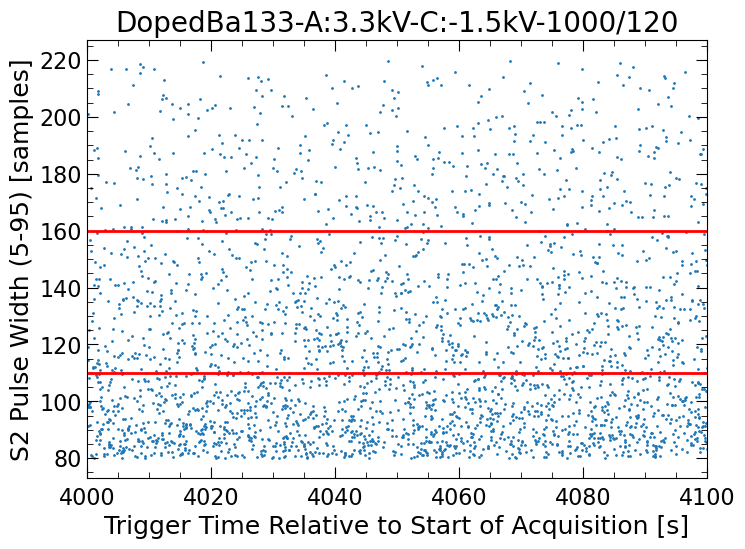

In [5]:
#Plots for cut verification and checks
pulse_width_cutoffs = [[110, 160],
                       #[125, 182],
                       [110, 160],
                       [110, 160],
                       [110, 160]]
i=0
for label in file_list_labels:
    plt.scatter(RQs[label]['ss_trig_timestamp'], RQs[label]['ss_s2_width595'], s=1)
    plt.xlim(4000, 4100)
    plt.xlabel("Trigger Time Relative to Start of Acquisition [s]")
    plt.ylabel("S2 Pulse Width (5-95) [samples]")
    plt.axhline(pulse_width_cutoffs[i][0], color='red')
    plt.axhline(pulse_width_cutoffs[i][1], color='red')
    plt.title(label)
    plt.show()
    RQs[label]['pulse_width_cut'] = (RQs[label]['ss_s2_width595'] > pulse_width_cutoffs[i][0]) & (RQs[label]['ss_s2_width595'] < pulse_width_cutoffs[i][1])
    i=i+1

(200, 200)


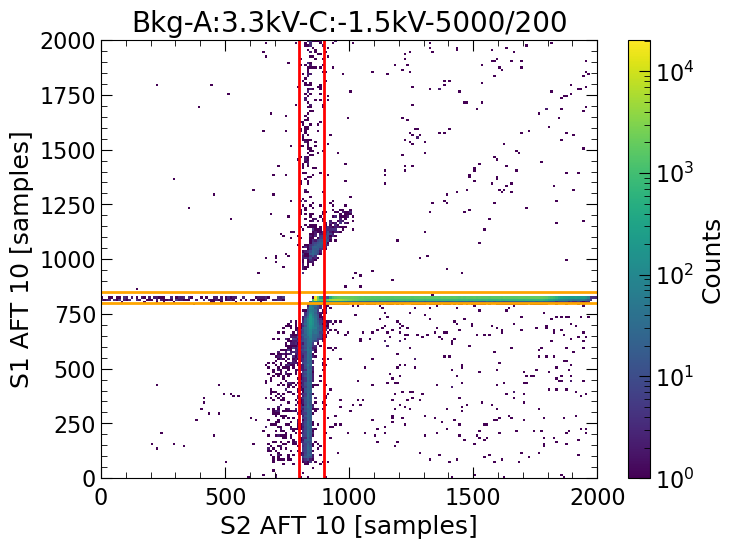

(200, 200)


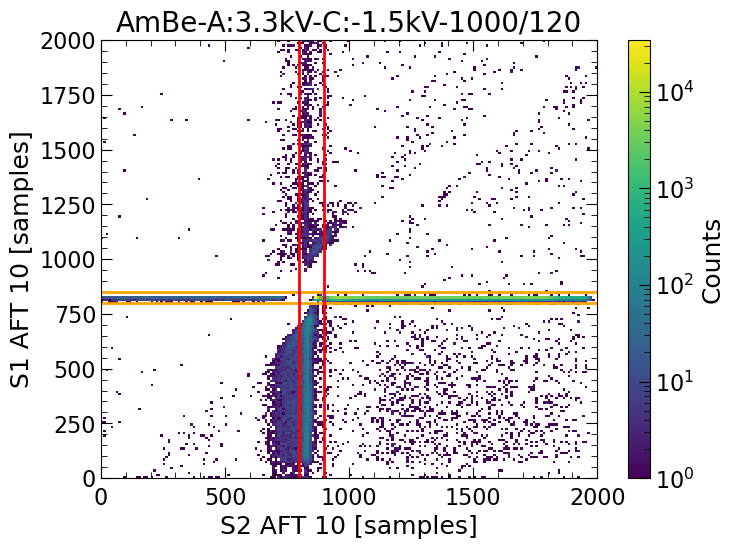

(200, 200)


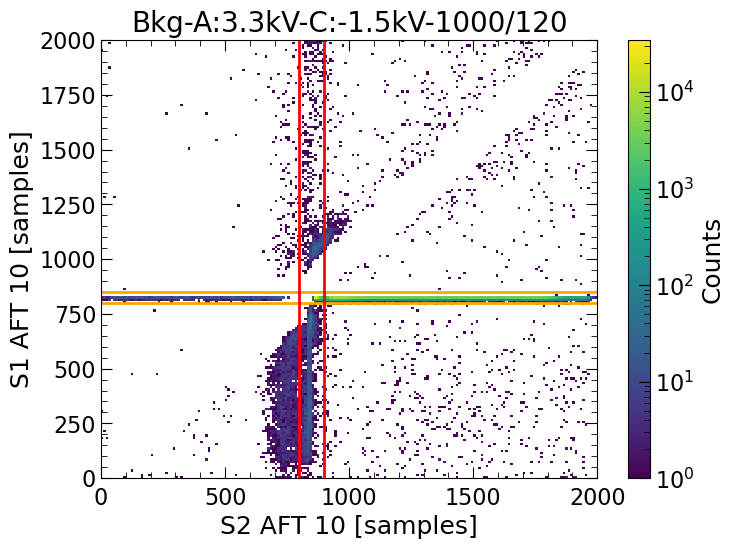

In [34]:
trigger_cutoffs = [[800, 850, 800, 900],
                   #[950, 1000, 950, 1050],
                   [800, 850, 800, 900],
                   [800, 850, 800, 900],
                   [800, 850, 800, 900]]
i=0
for label in file_list_labels:
    plot2d(RQs[label]['ss_s2_aft10'], RQs[label]['ss_s1_aft10'], (0,2e3), (0, 2e3), x_bins=200, y_bins=200, flag_log=True)
    plt.xlabel("S2 AFT 10 [samples]")
    plt.ylabel("S1 AFT 10 [samples]")
    plt.colorbar(label="Counts")
    plt.axhline(y=trigger_cutoffs[i][0], color='orange')
    plt.axhline(y=trigger_cutoffs[i][1], color='orange')
    plt.axvline(x=trigger_cutoffs[i][2], color='red')
    plt.axvline(x=trigger_cutoffs[i][3], color='red')
    plt.title(label)
    plt.show()
    RQs[label]['s1_trigger_cut'] = ((RQs[label]['ss_s1_aft10'] > trigger_cutoffs[i][0]) & (RQs[label]['ss_s1_aft10'] < trigger_cutoffs[i][1])) 
    RQs[label]['s2_trigger_cut'] = ((RQs[label]['ss_s2_aft10'] > trigger_cutoffs[i][2]) & (RQs[label]['ss_s2_aft10'] < trigger_cutoffs[i][3]))
    i=i+1

/tmp/ipykernel_652265/877936398.py:16: RuntimeWarning: invalid value encountered in log10
  RQs[label]['bad_area_cut'] = ((RQs[label]['ss_bad_area'] < 0.8*np.log10(RQs[label]['ss_good_area'])**5) & (RQs[label]['ss_bad_area'] > 1e-2))


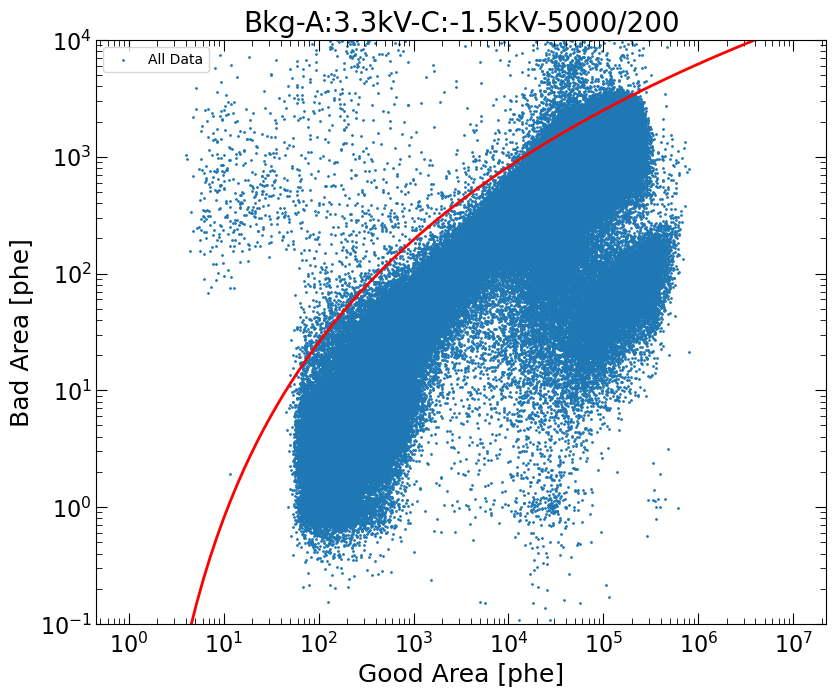

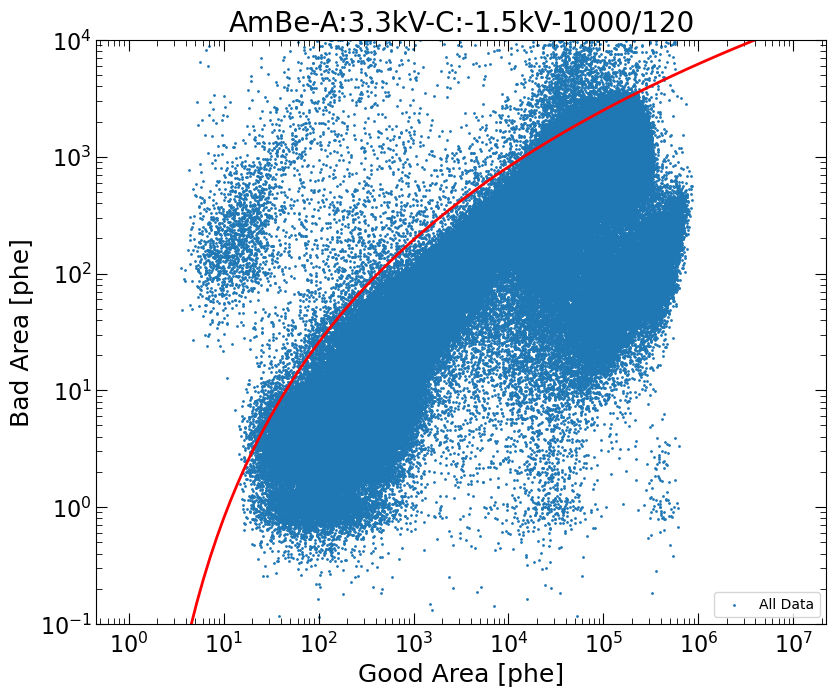

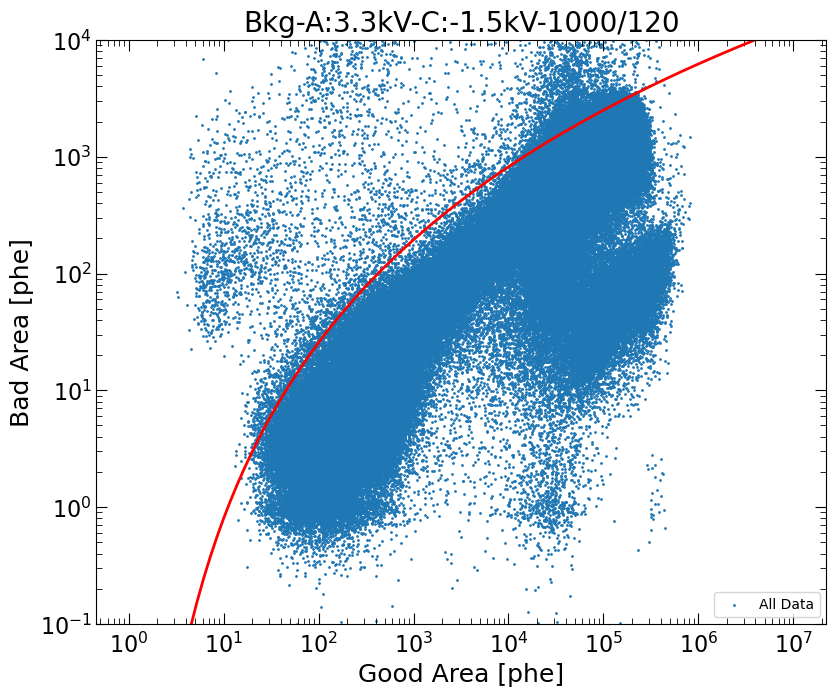

In [35]:
for label in file_list_labels:
    bad_area = RQs[label]['ss_bad_area']
    good_area = RQs[label]['ss_good_area']
    plt.figure(figsize=(10,8))
    plt.scatter(good_area, bad_area, s=1, label='All Data')
    plt.plot(np.logspace(0.01,7,100), 0.8*np.log10(np.logspace(0.01,7,100))**5, color='red')
    plt.legend()
    plt.axhline(y=1e-2, color='red')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Good Area [phe]")
    plt.ylabel("Bad Area [phe]")
    plt.title(label)
    plt.ylim(1e-1, 1e4)
    #plt.xlim(5e1, 4e2)
    RQs[label]['bad_area_cut'] = ((RQs[label]['ss_bad_area'] < 0.8*np.log10(RQs[label]['ss_good_area'])**5) & (RQs[label]['ss_bad_area'] > 1e-2))

(100, 100)


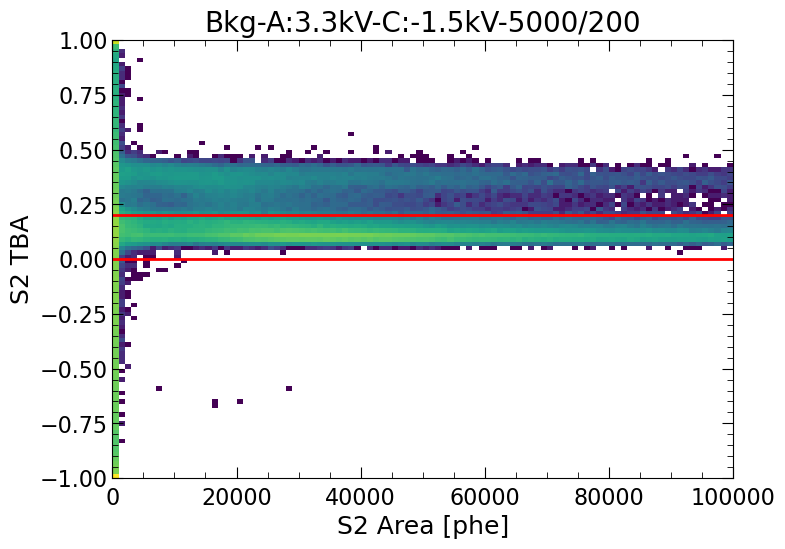

(100, 100)


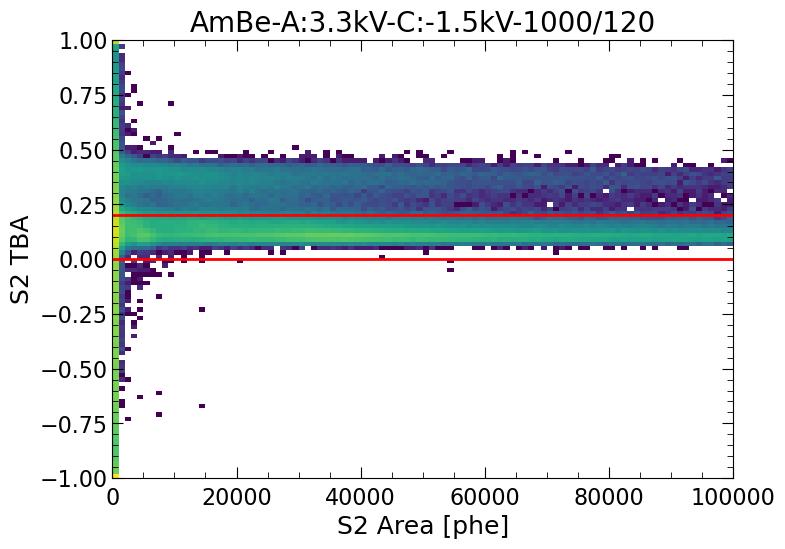

(100, 100)


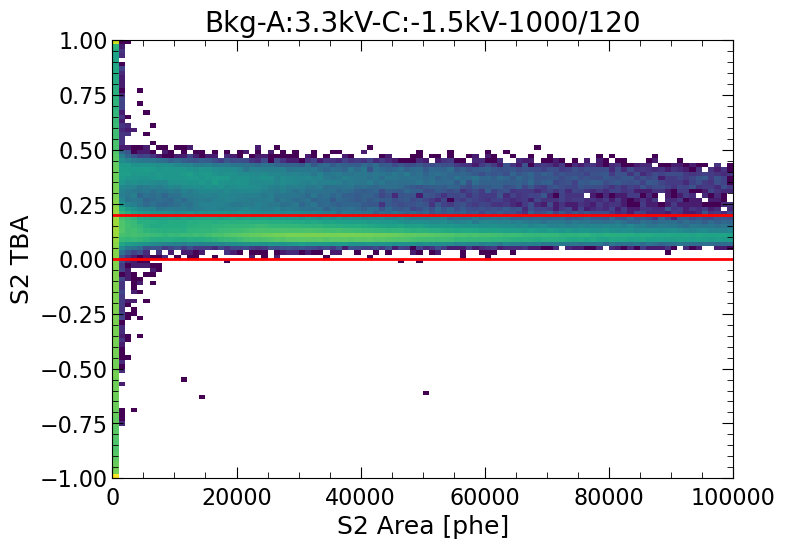

In [36]:
pulseS2TBACutoffs = [0, 0.2]

for label in file_list_labels:
    plot2d(RQs[label]['ss_s2_area'], RQs[label]['ss_s2_tba'], (0,1e5), (-1, 1), x_bins=100, y_bins=100, flag_log=True)
    plt.xlabel("S2 Area [phe]")
    plt.ylabel("S2 TBA")
    plt.axhline(y=pulseS2TBACutoffs[0], color='red')
    plt.axhline(y=pulseS2TBACutoffs[1], color='red')
    plt.title(label)
    plt.show()
    RQs[label]['tba_cut'] = ((RQs[label]['ss_s2_tba'] < pulseS2TBACutoffs[1]) & (RQs[label]['ss_s2_tba'] > pulseS2TBACutoffs[0]))

(200, 200)


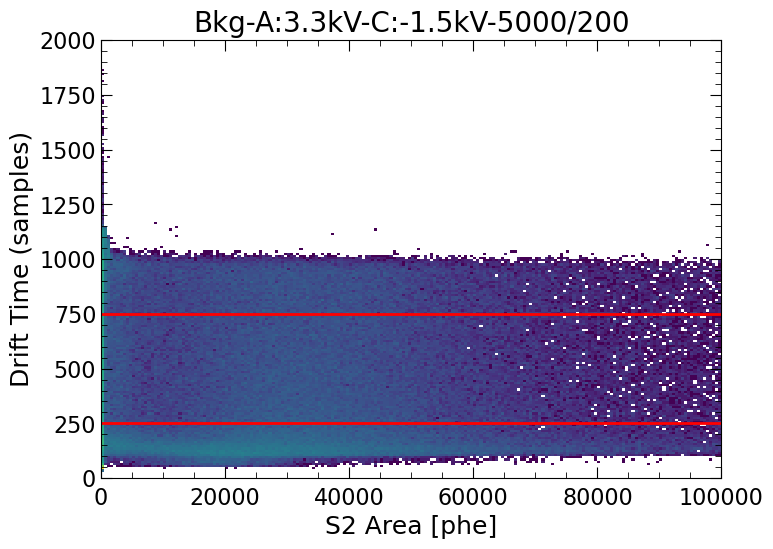

(200, 200)


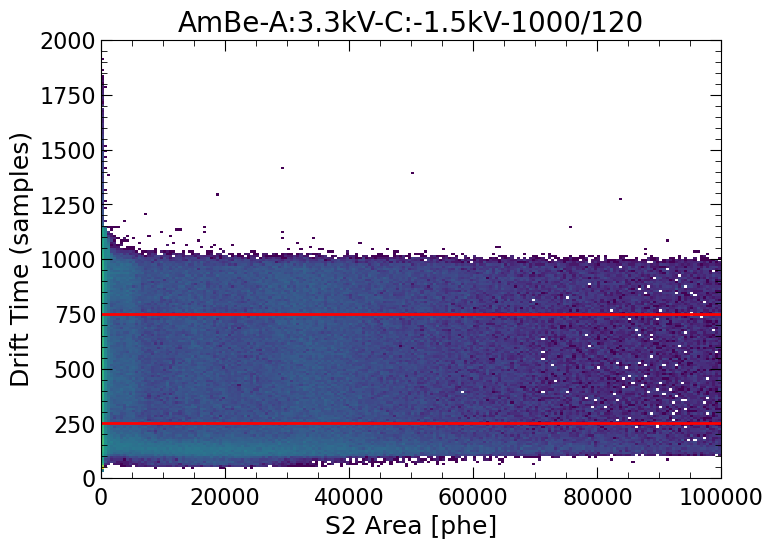

(200, 200)


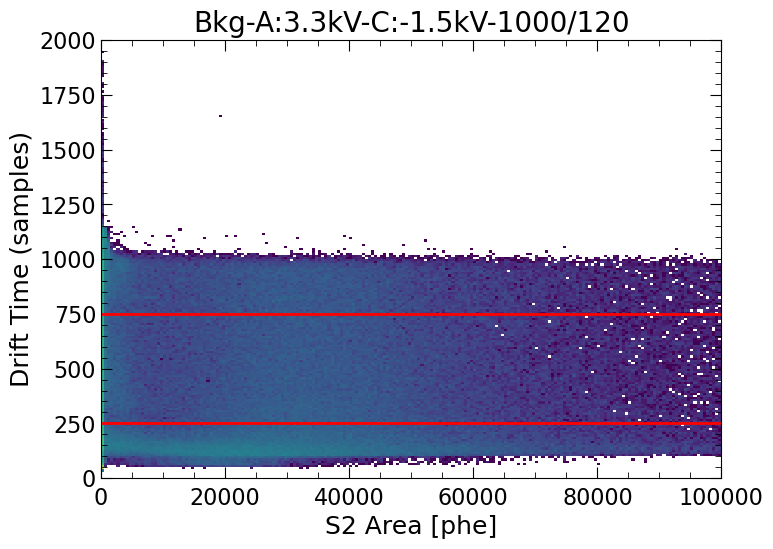

In [37]:
drift_time_cutoffs = [250, 750]

for label in file_list_labels:
    plot2d(RQs[label]['ss_s2_area'], RQs[label]['ss_s2_drift_time'], (0,1e5), (0, 2e3), x_bins=200, y_bins=200, flag_log=True)
    plt.xlabel("S2 Area [phe]")
    plt.ylabel("Drift Time (samples)")
    plt.axhline(y=drift_time_cutoffs[0], color='red')
    plt.axhline(y=drift_time_cutoffs[1], color='red')
    plt.title(label)
    plt.show()
    RQs[label]['drift_time_cut'] = ((RQs[label]['ss_s2_drift_time'] < drift_time_cutoffs[1]) & (RQs[label]['ss_s2_drift_time'] > drift_time_cutoffs[0]))

(200, 200)


/tmp/ipykernel_652265/2445787111.py:3: RuntimeWarning: divide by zero encountered in power
  plt.plot(np.linspace(0,1000,100), 1.3*np.linspace(0,1000,100)**-0.7+0.08, color='red')


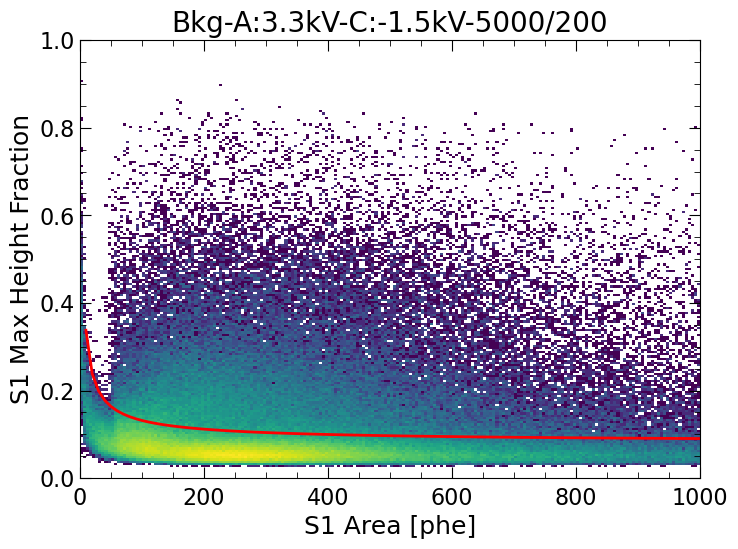

(200, 200)


/tmp/ipykernel_652265/2445787111.py:8: RuntimeWarning: invalid value encountered in power
  RQs[label]['mhf_cut'] = (RQs[label]['ss_s1_mhf'] < 1.3*RQs[label]['ss_s1_area']**-0.7+0.08)


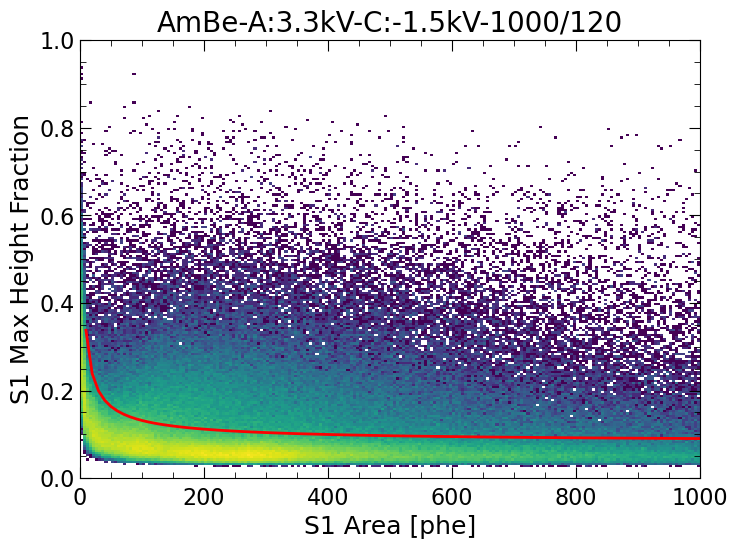

(200, 200)


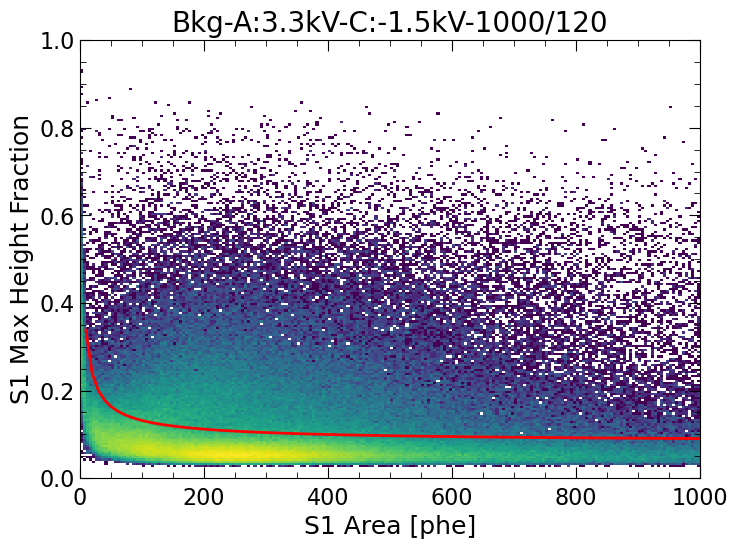

In [38]:
for label in file_list_labels:
    plot2d(RQs[label]['ss_s1_area'], RQs[label]['ss_s1_mhf'], (0,1e3), (0, 1), x_bins=200, y_bins=200, flag_log=True)
    plt.plot(np.linspace(0,1000,100), 1.3*np.linspace(0,1000,100)**-0.7+0.08, color='red')
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("S1 Max Height Fraction")
    plt.title(label)
    plt.show()
    RQs[label]['mhf_cut'] = (RQs[label]['ss_s1_mhf'] < 1.3*RQs[label]['ss_s1_area']**-0.7+0.08)

(100, 100)


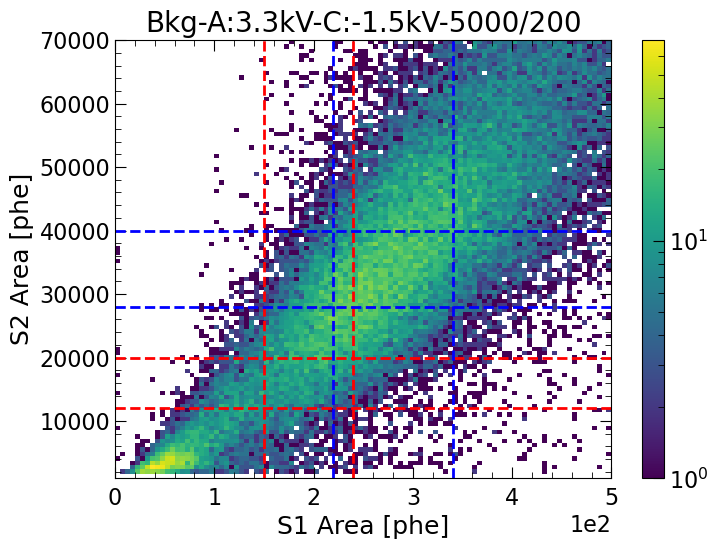

(150, 150)


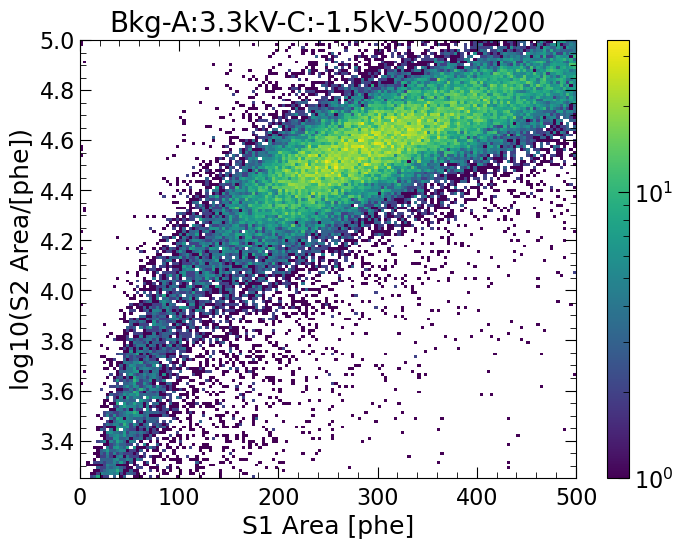

(100, 100)


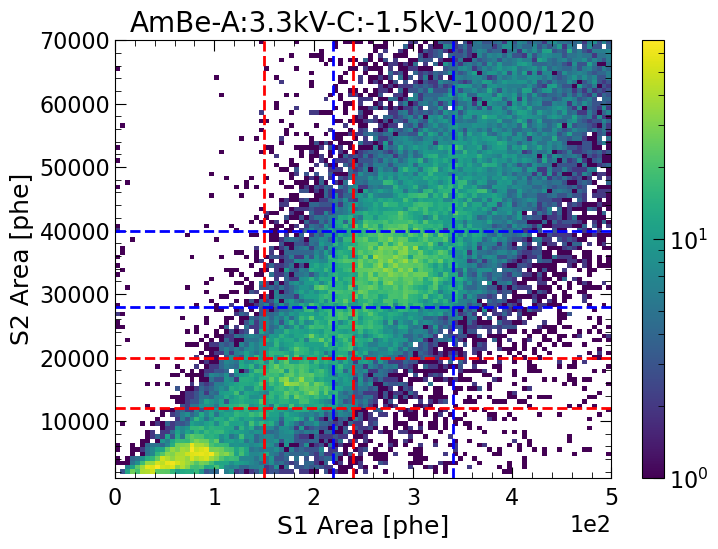

(150, 150)


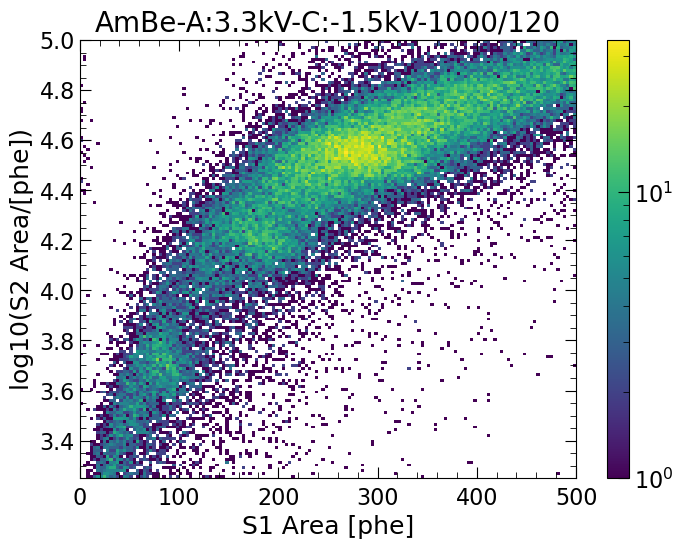

(100, 100)


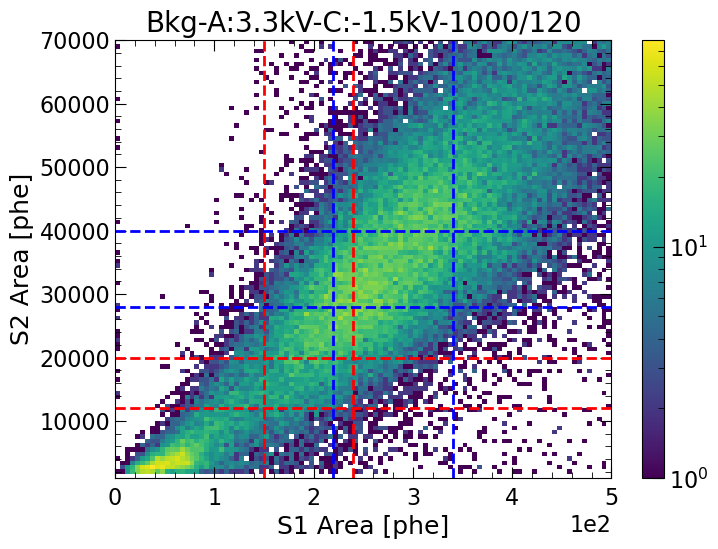

(150, 150)


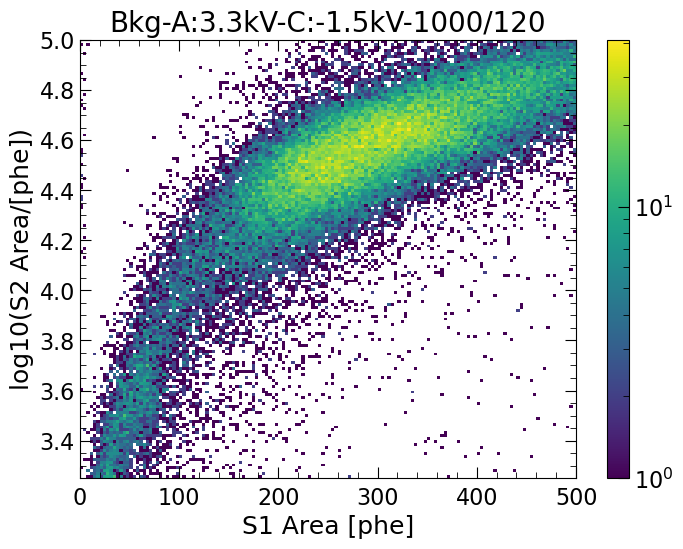

In [45]:
plot_bounds = [[5e2, 7e4, 5e2],
               #[5e2, 7e4, 2e2],
               [5e2, 7e4, 5e2],
               [5e2, 7e4, 5e2],
               [5e2, 7e4, 5e2],]

peak_bounds = [
    [[150, 240],[1.2e4, 2e4], [220, 340], [2.8e4, 4e4]],
    [[150, 240],[1.2e4, 2e4], [220, 340], [2.8e4, 4e4]],
    [[150, 240],[1.2e4, 2e4], [220, 340], [2.8e4, 4e4]],
    [[150, 240],[1.2e4, 2e4], [220, 340], [2.8e4, 4e4]],
]
i=0
for label in file_list_labels:
    single_acquistion = RQs[label]
    master_cut = single_acquistion['mhf_cut'] & single_acquistion['drift_time_cut'] & single_acquistion['tba_cut'] & single_acquistion['bad_area_cut'] & single_acquistion["pulse_width_cut"]
    s1_area_cut = single_acquistion['ss_s1_area'][master_cut]
    s2_area_cut = single_acquistion['ss_s2_area'][master_cut]

    plot2d(s1_area_cut[s2_area_cut>2000], s2_area_cut[s2_area_cut>2000], (0,plot_bounds[i][0]), (1e3, plot_bounds[i][1]), x_bins=100, y_bins=100, flag_log=True)
    plt.ticklabel_format(axis='both', style='sci', scilimits=(3,5))
    plt.colorbar()
    plt.axvline(x=peak_bounds[i][0][0], linestyle="--", color="red")
    plt.axvline(x=peak_bounds[i][0][1], linestyle="--", color="red")
    plt.axhline(y=peak_bounds[i][1][0], linestyle="--", color="red")
    plt.axhline(y=peak_bounds[i][1][1], linestyle="--", color="red")

    plt.axvline(x=peak_bounds[i][2][0], linestyle="--", color="blue")
    plt.axvline(x=peak_bounds[i][2][1], linestyle="--", color="blue")
    plt.axhline(y=peak_bounds[i][3][0], linestyle="--", color="blue")
    plt.axhline(y=peak_bounds[i][3][1], linestyle="--", color="blue")
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("S2 Area [phe]")
    plt.title(label)
    plt.show()

    plot2d(s1_area_cut, np.log10(s2_area_cut), (0,plot_bounds[i][2]), (3.25, 5), x_bins=150, y_bins=150, flag_log=True)
    plt.colorbar()
    #plt.ticklabel_format(axis='both', style='sci', scilimits=(3,1))
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("log10(S2 Area/[phe])")
    plt.title(label)
    plt.show()
    i=i+1
    RQs[label]['peak1_cut'] = (RQs[label]['ss_s2_area'] < peak_bounds[i][1][1]) & (RQs[label]['ss_s2_area'] < peak_bounds[i][1][1])
    RQs[label]['peak2_cut'] = (RQs[label]['ss_s2_area'] < peak_bounds[i][3][1]) & (RQs[label]['ss_s2_area'] < peak_bounds[i][3][1])

(200, 200)


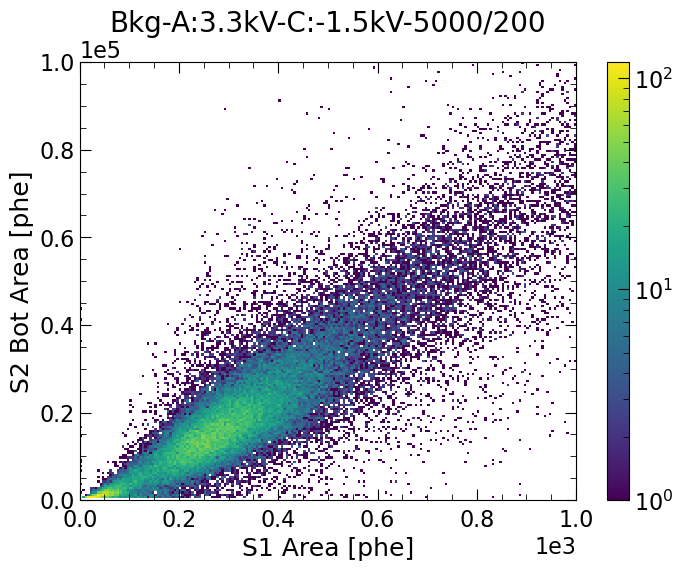

(150, 150)


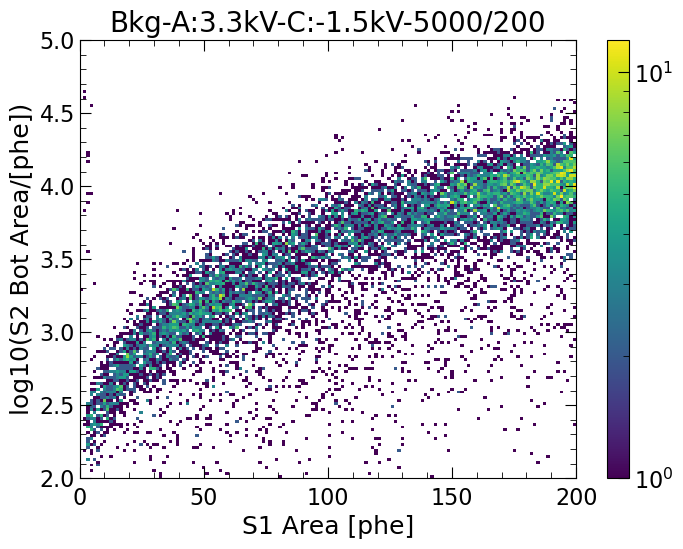

(200, 200)


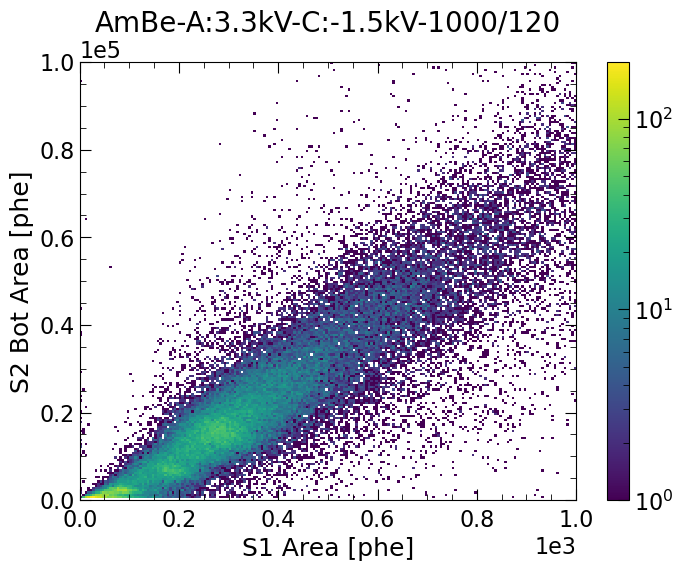

(150, 150)


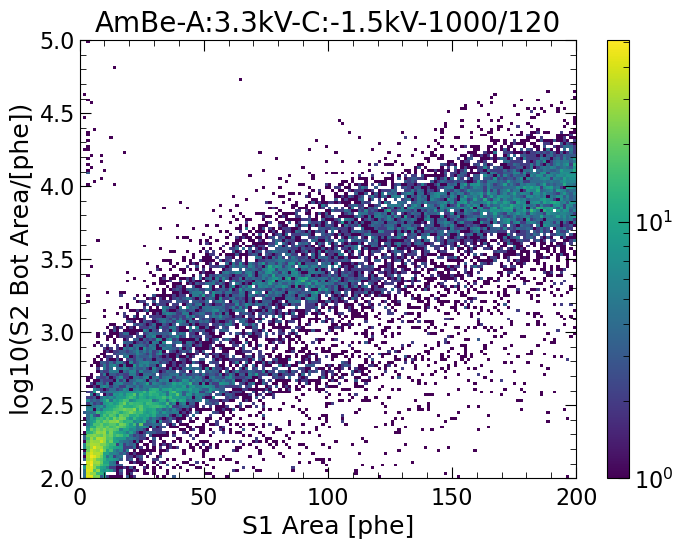

(200, 200)


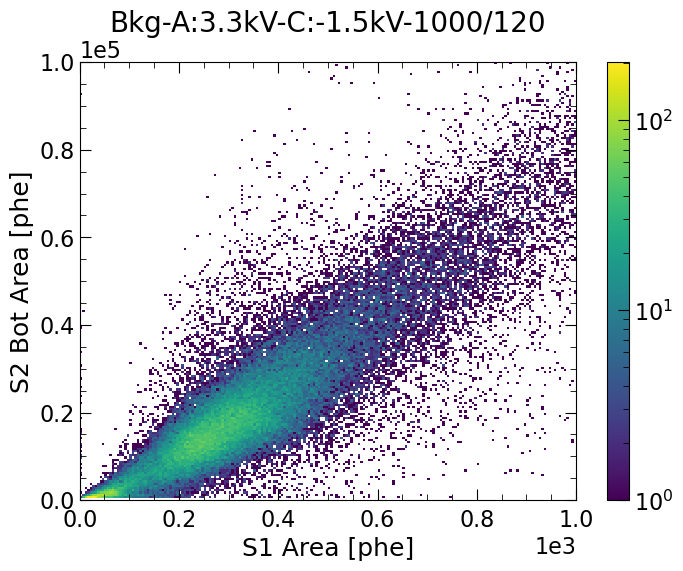

(150, 150)


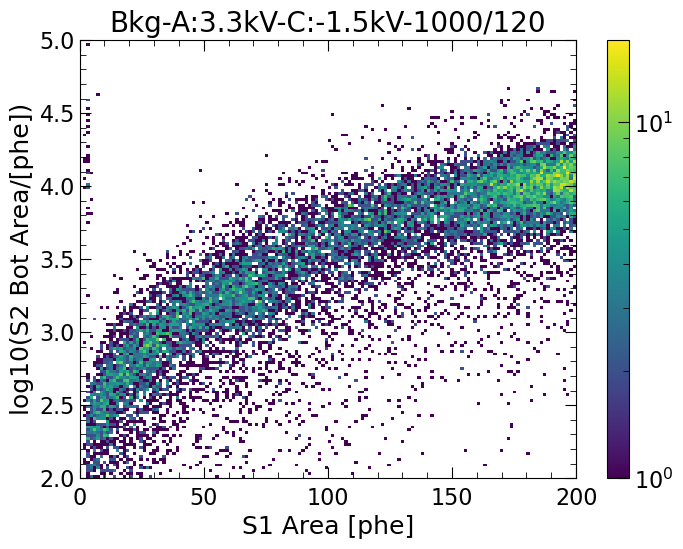

In [40]:
plot_bounds = [#[1e3, 7.5e4, 2e2],
               [1e3, 1e5, 2e2],
               [1e3, 1e5, 2e2],
               [1e3, 1e5, 2e2],
               [1e3, 1e5, 2e2]]
i=0
for label in file_list_labels:
    single_acquistion = RQs[label]
    master_cut = single_acquistion['mhf_cut'] & single_acquistion['drift_time_cut'] & single_acquistion['tba_cut'] & single_acquistion['bad_area_cut'] & single_acquistion["pulse_width_cut"]
    s1_area_cut = single_acquistion['ss_s1_area'][master_cut]
    s2_area_cut = single_acquistion['ss_s2_bot'][master_cut]

    plot2d(s1_area_cut[s2_area_cut>500], s2_area_cut[s2_area_cut>500], (0,plot_bounds[i][0]), (0, plot_bounds[i][1]), x_bins=200, y_bins=200, flag_log=True)
    plt.ticklabel_format(axis='both', style='sci', scilimits=(3,5))
    plt.colorbar()
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("S2 Bot Area [phe]")
    plt.title(label)
    plt.show()

    plot2d(s1_area_cut, np.log10(s2_area_cut), (0,plot_bounds[i][2]), (2, 5), x_bins=150, y_bins=150, flag_log=True)
    plt.colorbar()
    #plt.ticklabel_format(axis='both', style='sci', scilimits=(3,1))
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("log10(S2 Bot Area/[phe])")
    plt.title(label)
    plt.show()
    i=i+1

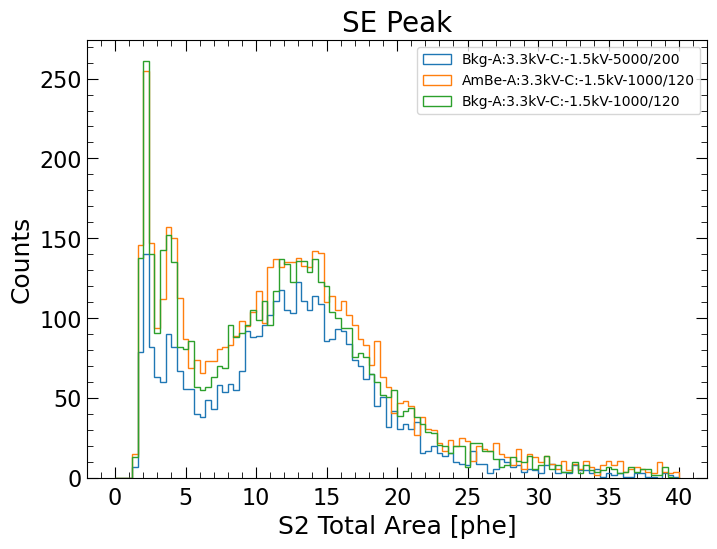

In [41]:
for i in range(3):
    #if i % 2 == 1:
    label = file_list_labels[i]
    single_acquistion = RQs[label]
    master_cut = single_acquistion['drift_time_cut'] & single_acquistion['tba_cut'] & single_acquistion['bad_area_cut']
    s2_area_cut = single_acquistion['ss_s2_area'][master_cut]
    plt.hist(s2_area_cut, bins=100, range=(0,40), histtype="step", label = label)
    plt.legend()
    plt.title("SE Peak")
    plt.ylabel("Counts")
    plt.xlabel("S2 Total Area [phe]")

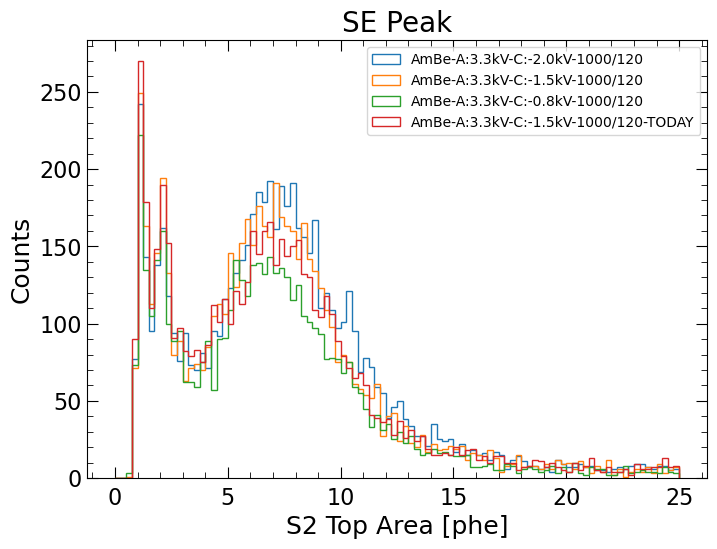

In [22]:
for i in range(4):
    #if i % 2 == 1:
    label = file_list_labels[i]
    single_acquistion = RQs[label]
    master_cut = single_acquistion['drift_time_cut'] & single_acquistion['tba_cut'] & single_acquistion['bad_area_cut']
    s2_area_cut = single_acquistion['ss_s2_top'][master_cut]
    plt.hist(s2_area_cut, bins=100, range=(0,25), histtype="step", label = label)
    plt.legend()
    plt.title("SE Peak")
    plt.ylabel("Counts")
    plt.xlabel("S2 Top Area [phe]")

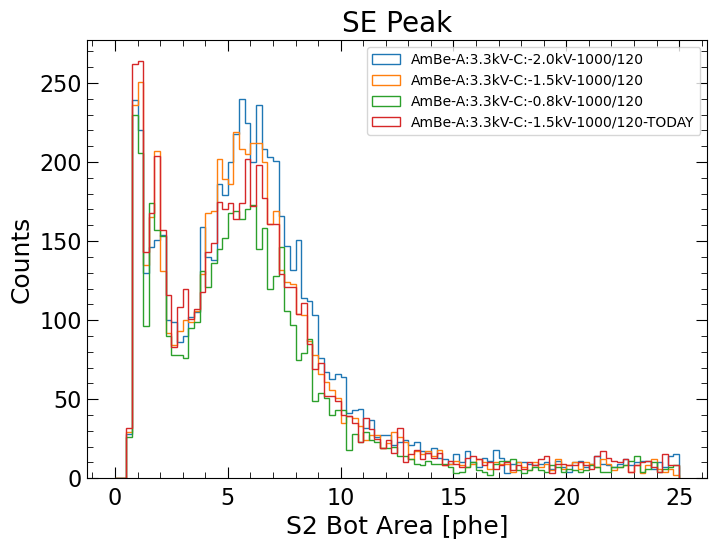

In [23]:
for i in range(4):
    #if i % 2 == 1:
    label = file_list_labels[i]
    single_acquistion = RQs[label]
    master_cut = single_acquistion['drift_time_cut'] & single_acquistion['tba_cut'] & single_acquistion['bad_area_cut']
    s2_area_cut = single_acquistion['ss_s2_bot'][master_cut]
    plt.hist(s2_area_cut, bins=100, range=(0,25), histtype="step", label = label)
    plt.legend()
    plt.title("SE Peak")
    plt.ylabel("Counts")
    plt.xlabel("S2 Bot Area [phe]")

Text(0.5, 0, 'S1 Area [phe]')

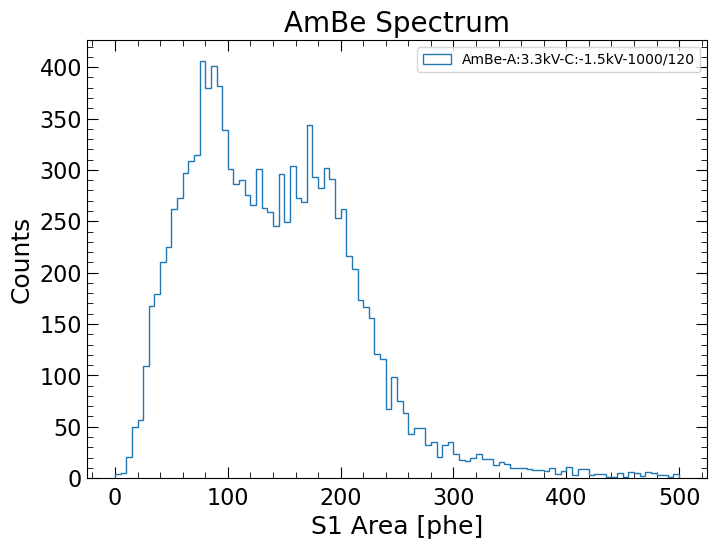

In [53]:
#for i in range(2):
    #if i % 2 == 1:
i=1
label = file_list_labels[i]
single_acquistion = RQs[label]
master_cut = single_acquistion['peak1_cut'] & single_acquistion['mhf_cut'] & single_acquistion['drift_time_cut'] & single_acquistion['tba_cut'] & single_acquistion['bad_area_cut'] & single_acquistion["pulse_width_cut"]
s1_area_cut = single_acquistion['ss_s1_area'][master_cut & (single_acquistion['ss_s2_area'] > 2e3)]
plt.hist(s1_area_cut, bins=100, range=(0,5e2), histtype="step", label = label)
#plt.yscale("log")
plt.legend()
plt.title("AmBe Spectrum")
plt.ylabel("Counts")
plt.xlabel("S1 Area [phe]")

(200, 200)


Text(0.5, 0, 'S2 X Position [mm]')

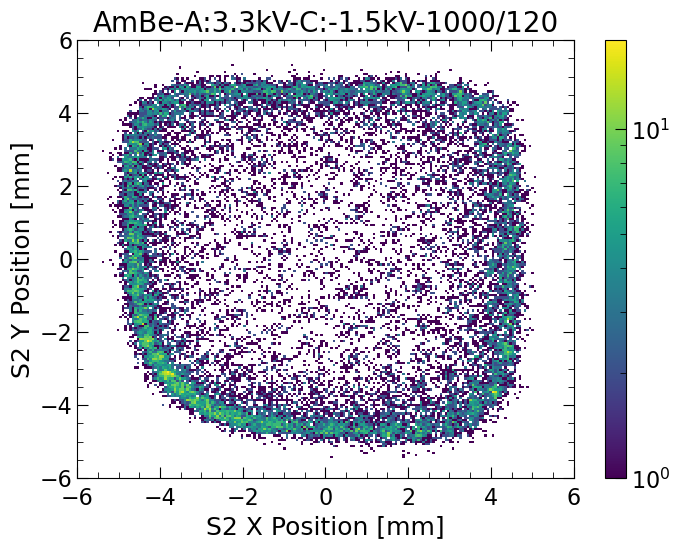

In [59]:
i=1
label = file_list_labels[i]
single_acquistion = RQs[label]
master_cut = single_acquistion['peak2_cut'] & single_acquistion['mhf_cut'] & single_acquistion['drift_time_cut'] & single_acquistion['tba_cut'] & single_acquistion['bad_area_cut'] & single_acquistion["pulse_width_cut"]
x_pos = single_acquistion['ss_s2_xpos'][master_cut & (single_acquistion['ss_s2_area'] > 2e3)]
y_pos = single_acquistion['ss_s2_ypos'][master_cut & (single_acquistion['ss_s2_area'] > 2e3)]
plot2d(x_pos, y_pos, (-6, 6), (-6, 6), x_bins=200, y_bins=200, flag_log=True)
#plt.yscale("log")
plt.colorbar()
plt.title(label)
plt.ylabel("S2 Y Position [mm]")
plt.xlabel("S2 X Position [mm]")

In [ ]:
|